In [1]:
import json
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")
np.random.seed(42)

plt.style.use("seaborn-v0_8")
sns.set_palette("viridis")
shap.initjs()


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Config


In [2]:
PATHS = {
    "train": "train_preprocessed.parquet",
    "val": "val_preprocessed.parquet",
    "test": "test_preprocessed.parquet",
    "meta": "pipeline_meta.json",
    "hybrid_pickle": "hybrid_model.pkl",    
}

BEST_PARAMS_HYBRID = None    
BEST_THRESHOLD = None       
MAX_SHAP_SAMPLES = 2_000
ZERO_RATIO = 0.40
TOP_N_DEPENDENCE = 6


# Feature engineering


In [3]:
def add_temporal_features(df):
    df = df.copy()
    df["Date"] = pd.to_datetime(df["Date"])
    df["Year"] = df["Date"].dt.year
    df["Month"] = df["Date"].dt.month
    df["Day"] = df["Date"].dt.day
    df["DayOfWeek"] = df["Date"].dt.dayofweek
    df["DayOfYear"] = df["Date"].dt.dayofyear
    df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)
    df["Is_Weekend"] = df["DayOfWeek"].isin([5, 6]).astype(int)
    return df


def add_lag_features(df, group_cols):
    df = df.sort_values(by=group_cols + ["Date"]).reset_index(drop=True)
    for lag in [7, 14, 30]:
        df[f"Demand_Lag_{lag}"] = df.groupby(group_cols)["Order_Demand"].shift(lag)
    for window in [7, 30]:
        df[f"Demand_Rolling_Mean_{window}"] = (
            df.groupby(group_cols)["Order_Demand"]
            .shift(1)
            .transform(lambda x: x.rolling(window, min_periods=1).mean())
        )
    fill_cols = [c for c in df.columns if "Lag_" in c or "Rolling_" in c]
    df[fill_cols] = df[fill_cols].fillna(0)
    return df


def add_advanced_intermittent_features(df, group_cols):
    df = df.sort_values(by=group_cols + ["Date"]).reset_index(drop=True)
    shifted = df.groupby(group_cols)["Order_Demand"].shift(1)
    for window in [7, 30]:
        df[f"Zero_Rate_{window}d"] = (
            shifted.transform(lambda x: (x == 0).rolling(window, min_periods=1).mean())
            .fillna(0.5)
        )

    def days_since_last_sale(series_dates, series_demand):
        result = np.zeros(len(series_demand), dtype=float)
        last_sale_date = None
        for i, (d, v) in enumerate(zip(series_dates, series_demand)):
            result[i] = -1 if last_sale_date is None else int(
                (d - last_sale_date) / np.timedelta64(1, "D")
            )
            if v > 0:
                last_sale_date = d
        return result

    df["Days_Since_Last_Sale"] = (
        df.groupby(group_cols, group_keys=False)
        .apply(lambda g: pd.Series(
            days_since_last_sale(g["Date"].values, g["Order_Demand"].values),
            index=g.index,
        ))
    )

    df["Demand_Velocity_7d"] = (
        df.groupby(group_cols)["Order_Demand"]
        .shift(1)
        .transform(lambda x: x.diff().abs().rolling(7, min_periods=1).mean())
        .fillna(0)
    )

    def consecutive_zeros(series):
        result, count = np.zeros(len(series)), 0
        for i, val in enumerate(series):
            result[i] = count
            count = count + 1 if val == 0 else 0
        return result

    df["Consecutive_Zeros"] = df.groupby(group_cols)["Order_Demand"].transform(
        lambda x: consecutive_zeros(x.values)
    )
    return df


def out_of_fold_target_encoding(train_df, val_df, test_df, col, target_col, global_mean, n_splits=5):
    enc_col = f"{col}_TE"
    train_df, val_df, test_df = train_df.copy(), val_df.copy(), test_df.copy()

    oof_enc = np.full(len(train_df), global_mean)
    kf = KFold(n_splits=n_splits, shuffle=False)
    for trn_idx, oof_idx in kf.split(train_df):
        fold_mean = train_df.iloc[trn_idx].groupby(col)[target_col].mean()
        oof_enc[oof_idx] = train_df.iloc[oof_idx][col].map(fold_mean).fillna(global_mean).values
    train_df[enc_col] = oof_enc

    full_mean = train_df.groupby(col)[target_col].mean()
    val_df[enc_col] = val_df[col].map(full_mean).fillna(global_mean)
    test_df[enc_col] = test_df[col].map(full_mean).fillna(global_mean)
    return train_df, val_df, test_df


def log_transform(y):
    return np.log1p(np.maximum(y, 0))


def inverse_log_transform(y_log):
    return np.maximum(np.expm1(y_log), 0)


def wape_score(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.sum(np.abs(y_true))
    return np.sum(np.abs(y_true - y_pred)) / denom * 100 if denom > 0 else np.nan


# Load data & rebuild X_train / X_val / X_test 


In [4]:
TARGET_COL = "Order_Demand"
GROUP_KEYS = ["Product_Code", "Warehouse"]

train_df = pd.read_parquet(PATHS["train"])
val_df = pd.read_parquet(PATHS["val"])
test_df = pd.read_parquet(PATHS["test"])

with open(PATHS["meta"]) as f:
    meta = json.load(f)

FEATURE_COLS = meta["feature_cols"]
global_mean = meta["global_mean"]

for df in [train_df, val_df, test_df]:
    df["Date"] = pd.to_datetime(df["Date"])

train_end = train_df["Date"].max()
val_end = val_df["Date"].max()

full_df = (
    pd.concat([train_df, val_df, test_df])
    .sort_values(by=GROUP_KEYS + ["Date"])
    .reset_index(drop=True)
)
full_df = add_temporal_features(full_df)
full_df = add_lag_features(full_df, GROUP_KEYS)
full_df = add_advanced_intermittent_features(full_df, GROUP_KEYS)

train_df = full_df[full_df["Date"] <= train_end].copy()
val_df = full_df[(full_df["Date"] > train_end) & (full_df["Date"] <= val_end)].copy()
test_df = full_df[full_df["Date"] > val_end].copy()

new_cols = [c for c in full_df.columns if c not in FEATURE_COLS + [TARGET_COL, "Date"] + GROUP_KEYS]
FEATURE_COLS += new_cols

for col in ["Product_Code", "Warehouse", "Demand_Cluster"]:
    if col in train_df.columns:
        train_df, val_df, test_df = out_of_fold_target_encoding(
            train_df, val_df, test_df, col, TARGET_COL, global_mean
        )
        enc_col = f"{col}_TE"
        if enc_col not in FEATURE_COLS:
            FEATURE_COLS.append(enc_col)

MODEL_FEATURES = [c for c in FEATURE_COLS if c not in ["Demand_Cluster", "Product_Code", "Warehouse"]]
MODEL_FEATURES = [c for c in MODEL_FEATURES if c in train_df.columns]

X_train, y_train = train_df[MODEL_FEATURES], train_df[TARGET_COL]
X_val, y_val = val_df[MODEL_FEATURES], val_df[TARGET_COL]
X_test, y_test = test_df[MODEL_FEATURES], test_df[TARGET_COL]

nonzero_tr = y_train > 0
nonzero_val = y_val > 0

print(f" Train : {len(X_train):,}  |  Val : {len(X_val):,}  |  Test : {len(X_test):,}")
print(f" MODEL_FEATURES ({len(MODEL_FEATURES)})")


 Train : 240,414  |  Val : 57,744  |  Test : 53,998
 MODEL_FEATURES (65)


In [5]:
if PATHS["hybrid_pickle"] is not None and Path(PATHS["hybrid_pickle"]).exists():
    with open(PATHS["hybrid_pickle"], "rb") as f:
        bundle = pickle.load(f)
    clf_tuned = bundle["clf_tuned"]
    cal_tuned = bundle["cal_tuned"]
    reg_tuned = bundle["reg_tuned"]
    best_threshold_optuna = bundle["threshold"]
    print(f"  Loaded Hybrid from {PATHS['hybrid_pickle']}  (threshold={best_threshold_optuna:.3f})")

else:
    bp = BEST_PARAMS_HYBRID or {
        "clf_lr": 0.05, "clf_max_depth": 6, "clf_num_leaves": 31, "clf_min_child": 20,
        "clf_subsample": 0.8, "clf_colsample": 0.8, "clf_reg_alpha": 1e-2, "clf_reg_lambda": 1e-2,
        "reg_lr": 0.05, "reg_max_depth": 6, "reg_num_leaves": 31, "reg_min_child": 20,
        "reg_subsample": 0.8, "reg_colsample": 0.8, "reg_reg_alpha": 1e-2, "reg_reg_lambda": 1e-2,
    }
    if BEST_PARAMS_HYBRID is None:
        print("  WARNING: BEST_PARAMS_HYBRID=None -> dùng config mặc định, KHÔNG phải bản Optuna đã tune.")

    clf_tuned = lgb.LGBMClassifier(
        n_estimators=1000, learning_rate=bp["clf_lr"], max_depth=bp["clf_max_depth"],
        num_leaves=bp["clf_num_leaves"], min_child_samples=bp["clf_min_child"],
        subsample=bp["clf_subsample"], colsample_bytree=bp["clf_colsample"],
        reg_alpha=bp["clf_reg_alpha"], reg_lambda=bp["clf_reg_lambda"],
        is_unbalance=True, random_state=42, n_jobs=-1, verbosity=-1,
    )
    clf_tuned.fit(
        X_train, (y_train > 0).astype(int),
        eval_set=[(X_val, (y_val > 0).astype(int))],
        callbacks=[lgb.early_stopping(50, verbose=False)],
    )
    cal_tuned = CalibratedClassifierCV(clf_tuned, cv="prefit", method="isotonic")
    cal_tuned.fit(X_val, (y_val > 0).astype(int))

    reg_tuned = lgb.LGBMRegressor(
        n_estimators=1000, learning_rate=bp["reg_lr"], max_depth=bp["reg_max_depth"],
        num_leaves=bp["reg_num_leaves"], min_child_samples=bp["reg_min_child"],
        subsample=bp["reg_subsample"], colsample_bytree=bp["reg_colsample"],
        reg_alpha=bp["reg_reg_alpha"], reg_lambda=bp["reg_reg_lambda"],
        random_state=42, n_jobs=-1, verbosity=-1,
    )
    reg_tuned.fit(
        X_train[nonzero_tr], log_transform(y_train[nonzero_tr].values),
        eval_set=[(X_val[nonzero_val], log_transform(y_val[nonzero_val].values))],
        callbacks=[lgb.early_stopping(50, verbose=False)],
    )

    if BEST_THRESHOLD is not None:
        best_threshold_optuna = BEST_THRESHOLD
    else:
        cal_probs_val = cal_tuned.predict_proba(X_val)[:, 1]
        demand_val = inverse_log_transform(reg_tuned.predict(X_val))
        best_threshold_optuna, best_w = 0.0, float("inf")
        for thr in np.arange(0.0, 0.55, 0.02):
            preds = np.where(cal_probs_val < thr, 0.0, demand_val)
            w = wape_score(y_val.values, preds)
            if w < best_w:
                best_w, best_threshold_optuna = w, thr
        print(f"  Searched threshold on Val -> {best_threshold_optuna:.3f}  (Val WAPE={best_w:.2f}%)")

    with open("hybrid_model.pkl", "wb") as f:
        pickle.dump(
            {"clf_tuned": clf_tuned, "cal_tuned": cal_tuned, "reg_tuned": reg_tuned,
             "threshold": best_threshold_optuna},
            f,
        )
    print("  Hybrid saved -> hybrid_model.pkl  (set PATHS['hybrid_pickle'] to reload)")

probs_test = cal_tuned.predict_proba(X_test)[:, 1]
demand_test = inverse_log_transform(reg_tuned.predict(X_test))
preds_test = np.where(probs_test < best_threshold_optuna, 0.0, demand_test)
print(f"  Test WAPE (Hybrid) = {wape_score(y_test.values, preds_test):.2f}%  | threshold={best_threshold_optuna:.3f}")


  Loaded Hybrid from hybrid_model.pkl  (threshold=0.073)
  Test WAPE (Hybrid) = 72.60%  | threshold=0.073


# SHAP explainers 

In [6]:
explainer_clf = shap.TreeExplainer(clf_tuned)
explainer_reg = shap.TreeExplainer(reg_tuned, feature_perturbation="tree_path_dependent")

expected_clf = float(np.array(explainer_clf.expected_value).ravel()[-1])
expected_reg = float(np.array(explainer_reg.expected_value).ravel()[0])

print(f" Classifier baseline (log-odds) : {expected_clf:.4f}  -> baseline P(demand>0) ~ {1/(1+np.exp(-expected_clf)):.3f}")
print(f" Regressor baseline (log-demand): {expected_reg:.4f}  -> baseline demand ~ {np.expm1(expected_reg):.2f}")


 Classifier baseline (log-odds) : -1.5758  -> baseline P(demand>0) ~ 0.171
 Regressor baseline (log-demand): 4.6996  -> baseline demand ~ 108.90


# Stratified sampling for SHAP

In [7]:
zero_idx = X_test.index[y_test == 0]
nonzero_idx = X_test.index[y_test > 0]

n_zero = min(int(MAX_SHAP_SAMPLES * ZERO_RATIO), len(zero_idx))
n_nonzero = min(MAX_SHAP_SAMPLES - n_zero, len(nonzero_idx))

rng = np.random.default_rng(42)
sampled_idx = np.concatenate([
    rng.choice(zero_idx, size=n_zero, replace=False),
    rng.choice(nonzero_idx, size=n_nonzero, replace=False),
])

X_shap = X_test.loc[sampled_idx].reset_index(drop=True)
y_shap = y_test.loc[sampled_idx].reset_index(drop=True)

nz_mask_shap = (y_shap.values > 0)
X_shap_nz = X_shap[nz_mask_shap].reset_index(drop=True)
y_shap_nz = y_shap[nz_mask_shap].reset_index(drop=True)

print(f" SHAP sample (classifier): {len(X_shap):,}  | zero={n_zero} ({n_zero/len(X_shap)*100:.0f}%)  non-zero={n_nonzero}")
print(f" SHAP sample (regressor, actual-nonzero subset): {len(X_shap_nz):,}")

shap_values_clf = explainer_clf.shap_values(X_shap)
if isinstance(shap_values_clf, list):
    shap_values_clf = shap_values_clf[1]
elif shap_values_clf.ndim == 3:
    shap_values_clf = shap_values_clf[:, :, 1]

explanation_clf = explainer_clf(X_shap)

shap_values_reg = explainer_reg.shap_values(X_shap_nz)
explanation_reg = explainer_reg(X_shap_nz)

print(f" SHAP matrix classifier: {shap_values_clf.shape}")
print(f" SHAP matrix regressor : {shap_values_reg.shape}")


 SHAP sample (classifier): 2,000  | zero=800 (40%)  non-zero=1200
 SHAP sample (regressor, actual-nonzero subset): 1,200
 SHAP matrix classifier: (2000, 65)
 SHAP matrix regressor : (1200, 65)


# Feature importance - Stage 1: Classifier 


In [8]:
importance_clf = (
    pd.DataFrame({
        "feature": MODEL_FEATURES,
        "mean_abs_shap": np.abs(shap_values_clf).mean(axis=0),
        "mean_shap": shap_values_clf.mean(axis=0),
    })
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)
importance_clf.index += 1
importance_clf.to_csv("shap_importance_classifier.csv", index_label="rank")

print(" TOP 15 — Classifier (log-odds space):")
print(importance_clf.head(15).to_string())


 TOP 15 — Classifier (log-odds space):
                       feature  mean_abs_shap  mean_shap
1               Is_Zero_Demand      17.355135   4.950260
2                Zero_Rate_30d       0.207315   0.035311
3                 Zero_Rate_7d       0.077126   0.017228
4       Weeks_Since_Last_Order       0.016953   0.004775
5                 Has_YoY_Data       0.006666  -0.005702
6                   SP500_Lag1       0.004974   0.004974
7         Days_Since_Last_Sale       0.003270   0.000468
8              Has_52W_History       0.002813  -0.002193
9        Demand_Rolling_Mean_7       0.002357  -0.000607
10                Week_Of_Year       0.001463  -0.000638
11  Industrial_Production_Lag1       0.001164  -0.001159
12                Warehouse_TE       0.001142   0.000469
13           Copper_Price_Lag1       0.001001   0.001001
14                   DayOfYear       0.000855  -0.000140
15           Demand_RollStd12W       0.000777   0.000089


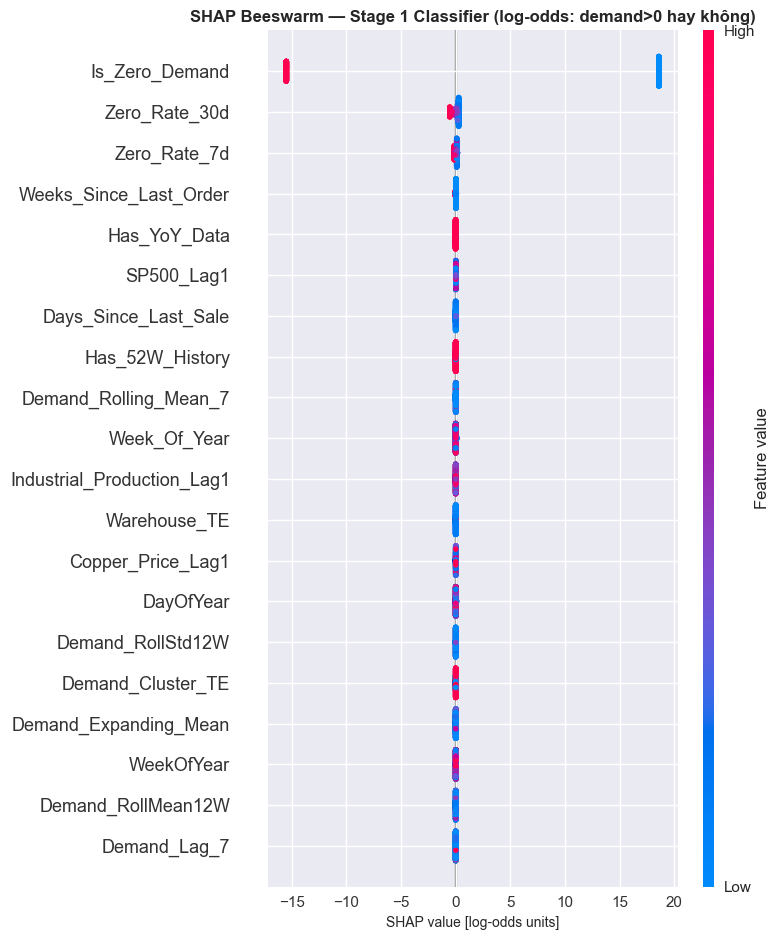

In [9]:
fig, _ = plt.subplots(figsize=(11, 8))
shap.summary_plot(shap_values_clf, X_shap, plot_type="dot", max_display=20, show=False)
plt.title("SHAP Beeswarm — Stage 1 Classifier (log-odds: demand>0 hay không)",
          fontsize=12, fontweight="bold")
plt.xlabel("SHAP value [log-odds units]", fontsize=10)
plt.tight_layout()
plt.show()


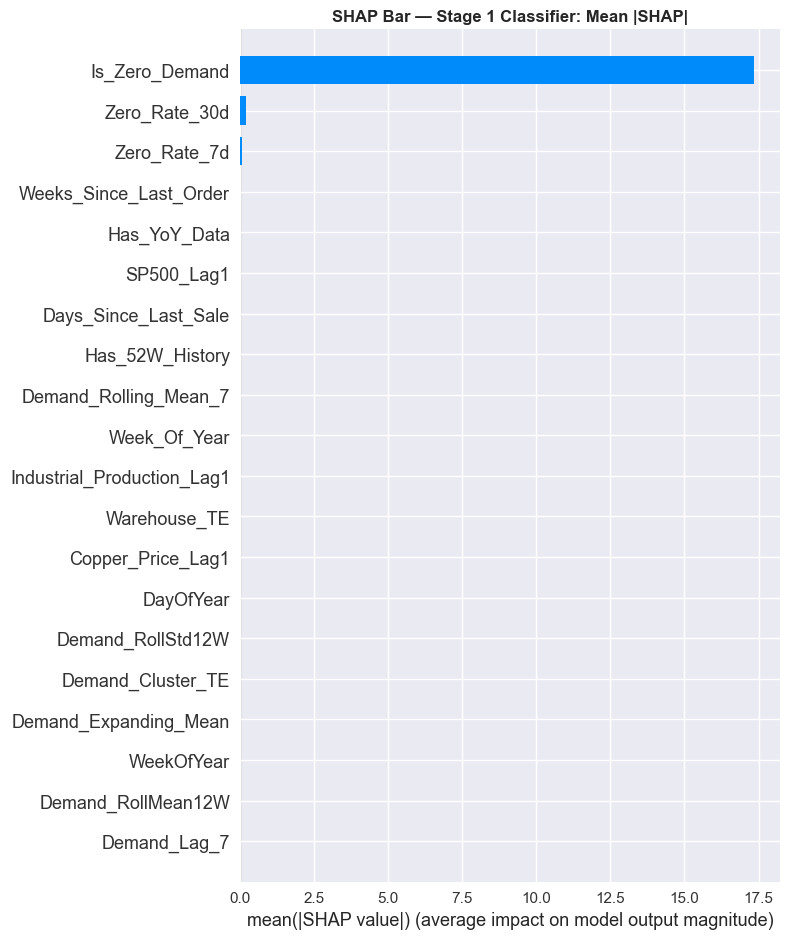

In [10]:
fig, _ = plt.subplots(figsize=(9, 7))
shap.summary_plot(shap_values_clf, X_shap, plot_type="bar", max_display=20, show=False)
plt.title("SHAP Bar — Stage 1 Classifier: Mean |SHAP|", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


# Feature importance - Stage 2: Regressor 


In [11]:
importance_reg = (
    pd.DataFrame({
        "feature": MODEL_FEATURES,
        "mean_abs_shap": np.abs(shap_values_reg).mean(axis=0),
        "mean_shap": shap_values_reg.mean(axis=0),
    })
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)
importance_reg.index += 1
importance_reg.to_csv("shap_importance_regressor.csv", index_label="rank")

print(" TOP 15 — Regressor (log-demand space, chỉ tính trên các dòng demand > 0):")
print(importance_reg.head(15).to_string())


 TOP 15 — Regressor (log-demand space, chỉ tính trên các dòng demand > 0):
                   feature  mean_abs_shap  mean_shap
1   Demand_Rolling_Mean_30       0.839280   0.047349
2       Demand_RollMean12W       0.633721   0.011005
3    Demand_Expanding_Mean       0.504304  -0.018391
4    Demand_Rolling_Mean_7       0.183008  -0.002697
5            Zero_Rate_30d       0.155733  -0.015132
6             Zero_Rate_7d       0.130337  -0.004379
7        Demand_RollStd12W       0.104675   0.035731
8        Demand_RollMean4W       0.079032  -0.003448
9        Demand_RollMean8W       0.062027  -0.007491
10       Demand_Cluster_TE       0.057860  -0.016158
11            Demand_Lag2W       0.046169   0.015628
12      Demand_Velocity_7d       0.043073   0.010377
13            Demand_Lag8W       0.036780   0.011167
14            Warehouse_TE       0.026753  -0.016504
15            Demand_Lag1W       0.026528   0.001736


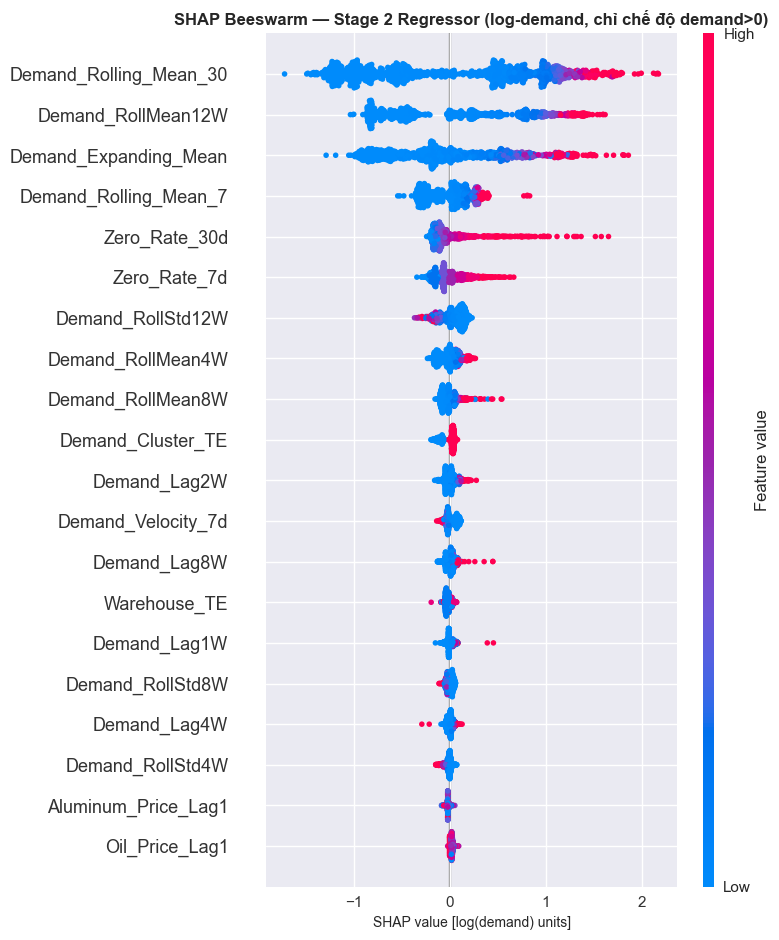

In [12]:
fig, _ = plt.subplots(figsize=(11, 8))
shap.summary_plot(shap_values_reg, X_shap_nz, plot_type="dot", max_display=20, show=False)
plt.title("SHAP Beeswarm — Stage 2 Regressor (log-demand, chỉ chế độ demand>0)",
          fontsize=12, fontweight="bold")
plt.xlabel("SHAP value [log(demand) units]", fontsize=10)
plt.tight_layout()
plt.show()


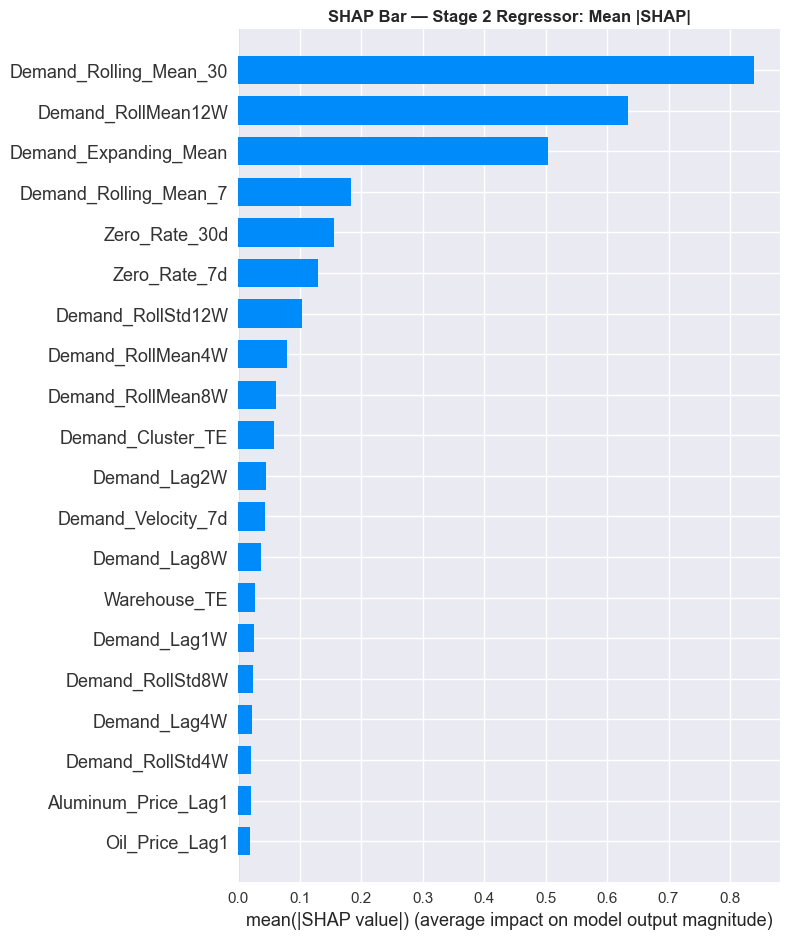

In [13]:
fig, _ = plt.subplots(figsize=(9, 7))
shap.summary_plot(shap_values_reg, X_shap_nz, plot_type="bar", max_display=20, show=False)
plt.title("SHAP Bar — Stage 2 Regressor: Mean |SHAP|", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


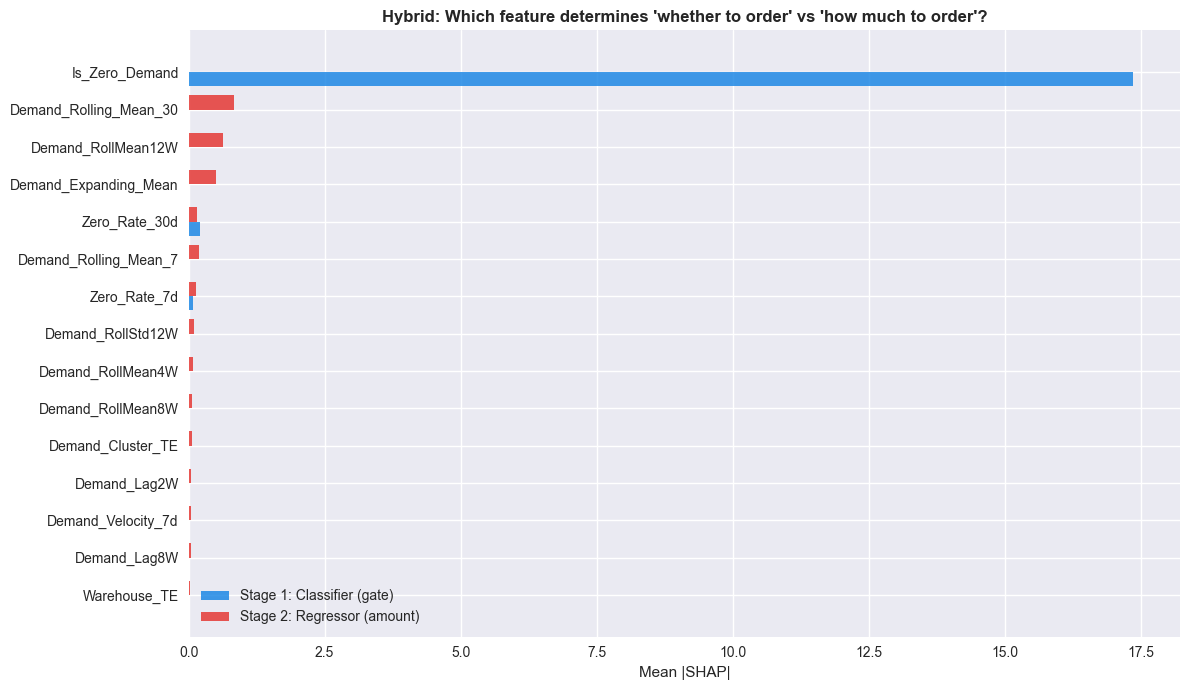

In [14]:
top_n_cmp = 15
combined = pd.merge(
    importance_clf[["feature", "mean_abs_shap"]].rename(columns={"mean_abs_shap": "clf_importance"}),
    importance_reg[["feature", "mean_abs_shap"]].rename(columns={"mean_abs_shap": "reg_importance"}),
    on="feature", how="outer",
).fillna(0)
combined["max_importance"] = combined[["clf_importance", "reg_importance"]].max(axis=1)
combined = combined.sort_values("max_importance", ascending=False).head(top_n_cmp)

fig, ax = plt.subplots(figsize=(12, 7))
y_pos = np.arange(len(combined))
bar_h = 0.38
ax.barh(y_pos + bar_h / 2, combined["clf_importance"], height=bar_h, color="#1E88E5",
        alpha=0.85, label="Stage 1: Classifier (gate)")
ax.barh(y_pos - bar_h / 2, combined["reg_importance"], height=bar_h, color="#E53935",
        alpha=0.85, label="Stage 2: Regressor (amount)")
ax.set_yticks(y_pos)
ax.set_yticklabels(combined["feature"], fontsize=10)
ax.invert_yaxis()
ax.set_xlabel("Mean |SHAP|", fontsize=11)
ax.set_title(
    "Hybrid: Which feature determines 'whether to order' vs 'how much to order'?",
    fontsize=12, fontweight="bold",
)
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


# Dependence plots - top features each stage


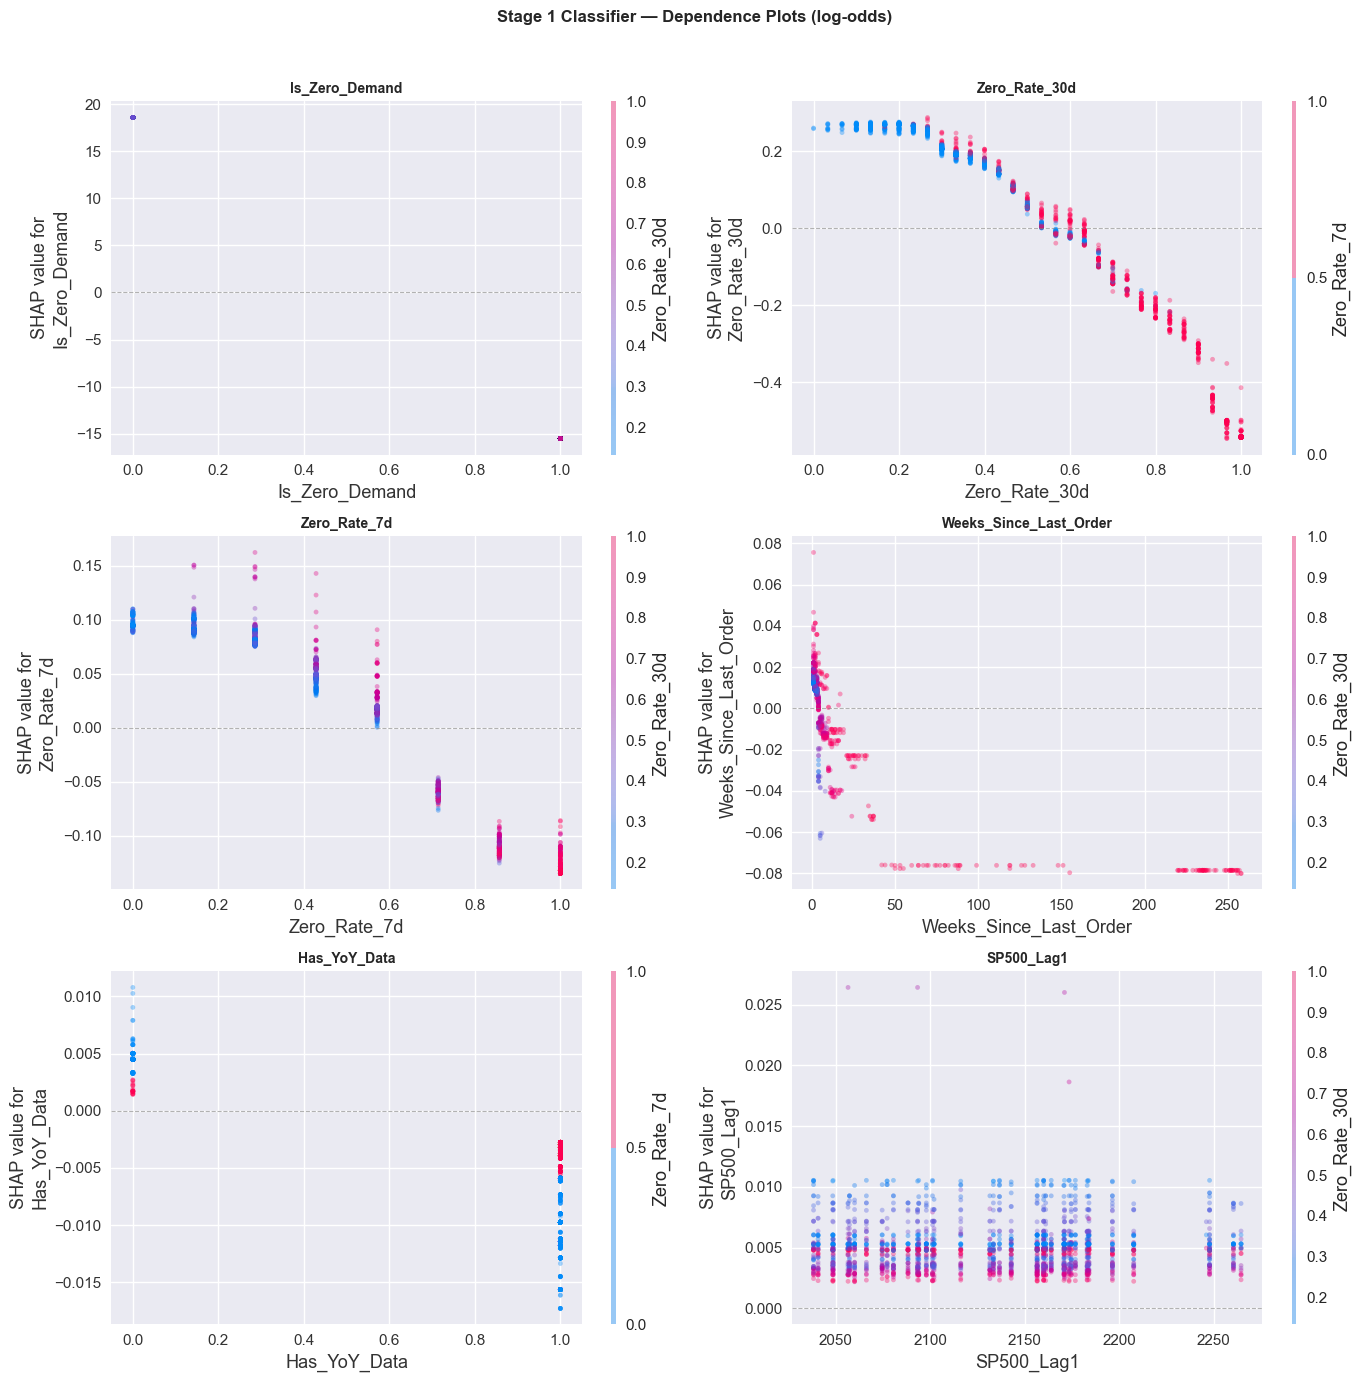

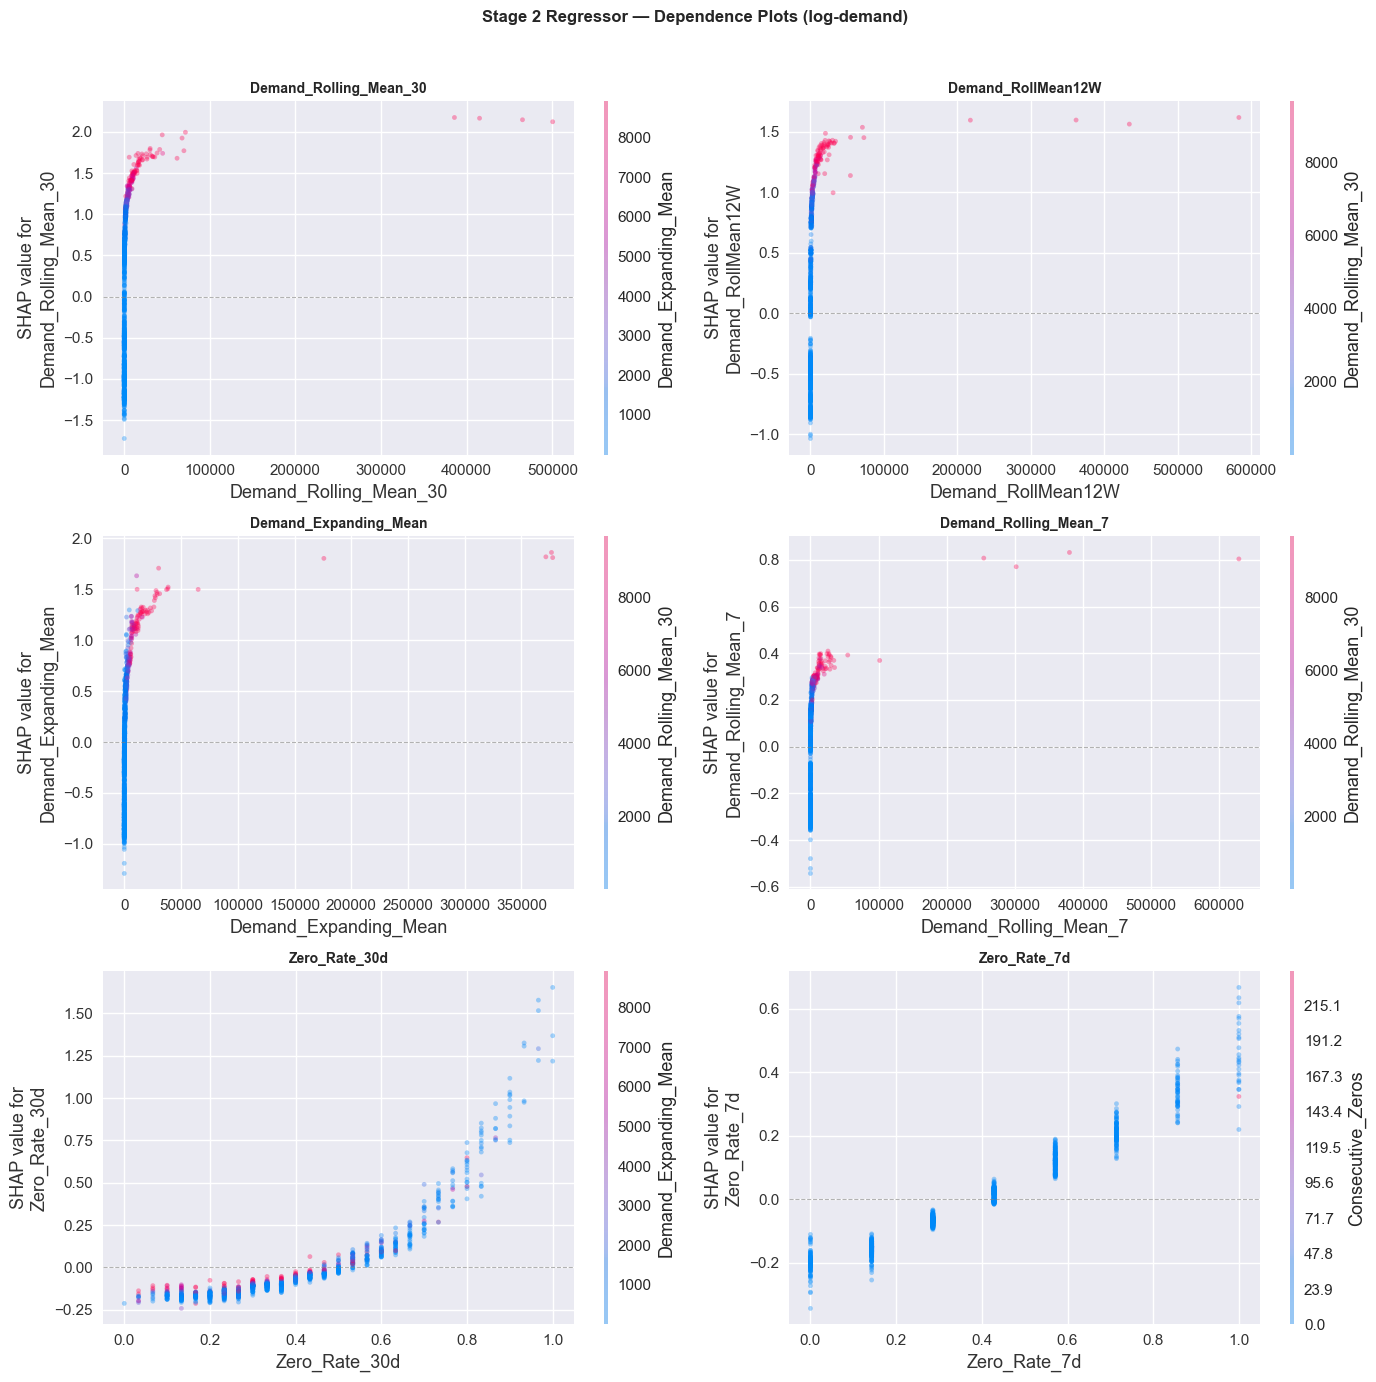

In [15]:
def plot_dependence(shap_values, X_data, importance_df, top_n, title):
    top_feats = importance_df.head(top_n)["feature"].tolist()
    n_cols = 2
    n_rows = (top_n + 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4.5 * n_rows))
    axes = axes.flatten()
    for i, feat in enumerate(top_feats):
        shap.dependence_plot(feat, shap_values, X_data, ax=axes[i], show=False, alpha=0.35, dot_size=12)
        axes[i].set_title(feat, fontsize=10, fontweight="bold")
        axes[i].axhline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.6)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    fig.suptitle(title, fontsize=12, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()


plot_dependence(shap_values_clf, X_shap, importance_clf, TOP_N_DEPENDENCE,
                 "Stage 1 Classifier — Dependence Plots (log-odds)")
plot_dependence(shap_values_reg, X_shap_nz, importance_reg, TOP_N_DEPENDENCE,
                 "Stage 2 Regressor — Dependence Plots (log-demand)")


# Local explanation

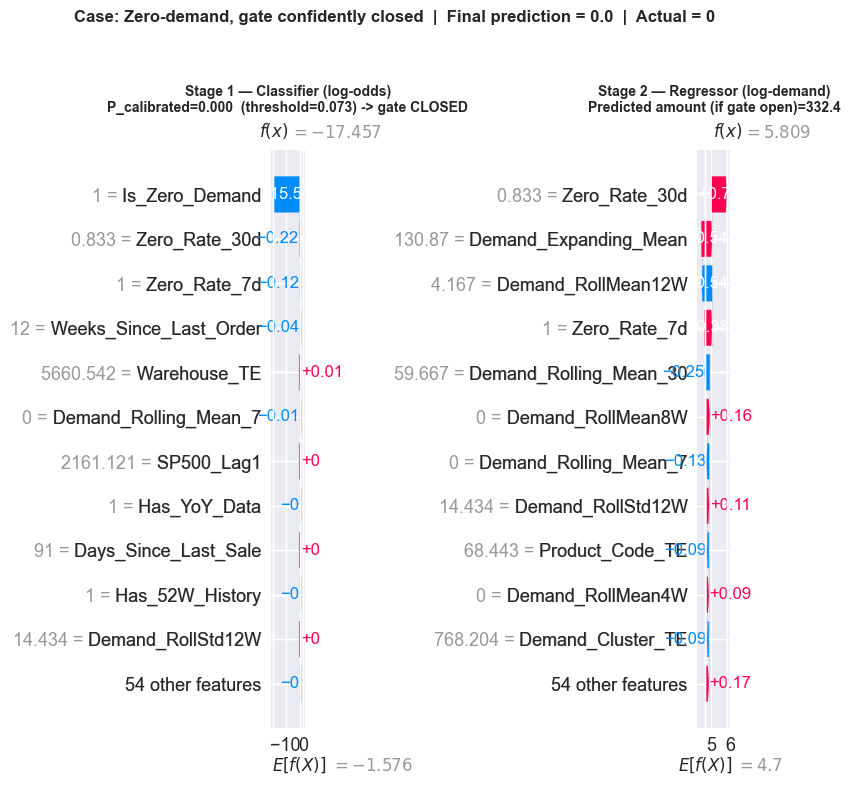

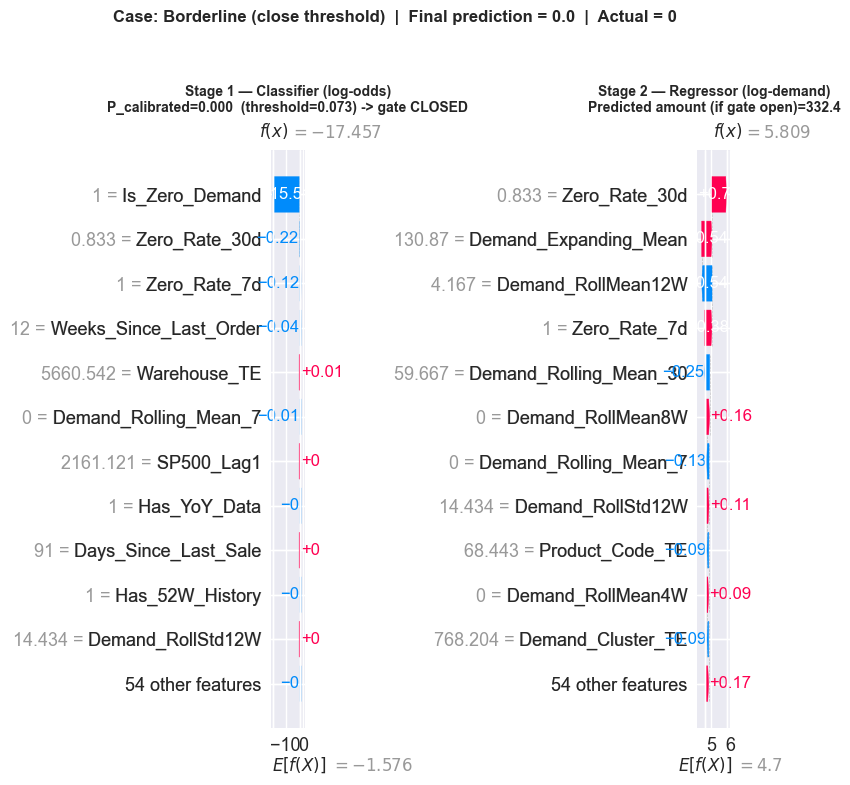

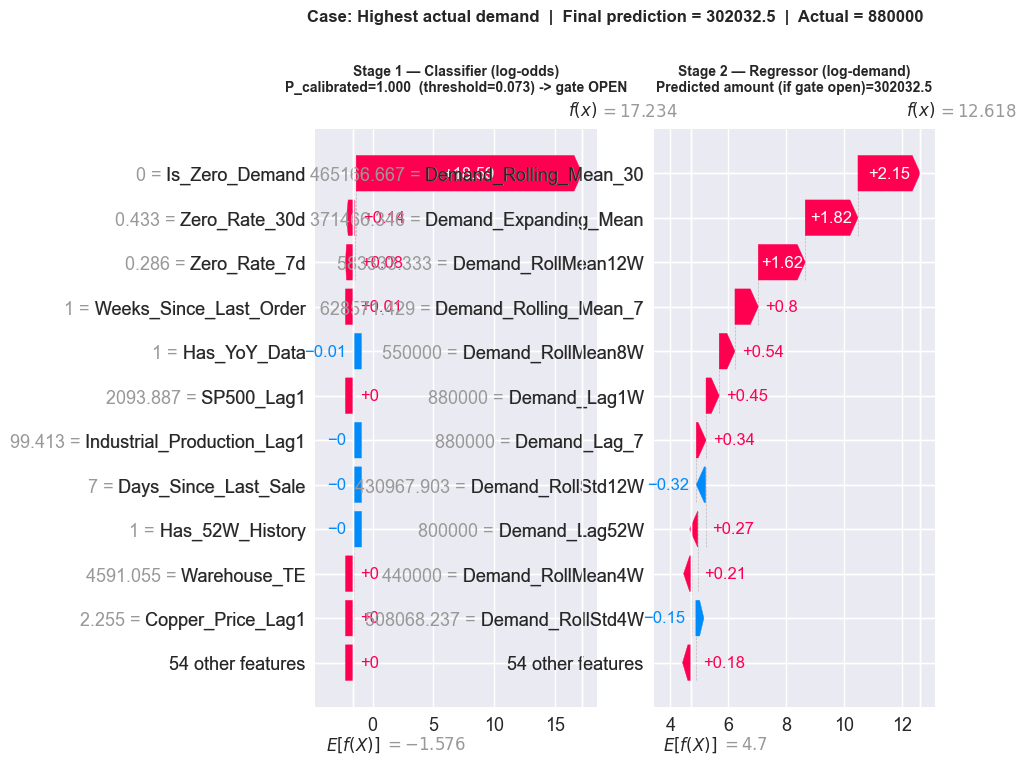

In [16]:
def explain_hybrid_sample(row_idx_in_shap, label=""):
    x_row = X_shap.iloc[[row_idx_in_shap]]
    prob_cal = cal_tuned.predict_proba(x_row)[0, 1]
    demand_if_nz = inverse_log_transform(reg_tuned.predict(x_row))[0]
    gate_open = prob_cal >= best_threshold_optuna
    final_pred = demand_if_nz if gate_open else 0.0
    actual = y_shap.iloc[row_idx_in_shap]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    plt.sca(axes[0])
    shap.plots.waterfall(explanation_clf[row_idx_in_shap], max_display=12, show=False)
    axes[0].set_title(f"Stage 1 — Classifier (log-odds)\nP_calibrated={prob_cal:.3f}  "
                       f"(threshold={best_threshold_optuna:.3f}) -> gate {'OPEN' if gate_open else 'CLOSED'}",
                       fontsize=10, fontweight="bold")

    match = X_shap_nz.index[(X_shap_nz.values == x_row.values).all(axis=1)] if len(X_shap_nz) else []
    plt.sca(axes[1])
    if len(match):
        shap.plots.waterfall(explanation_reg[match[0]], max_display=12, show=False)
    else:
        reg_expl_adhoc = explainer_reg(x_row)
        shap.plots.waterfall(reg_expl_adhoc[0], max_display=12, show=False)
    axes[1].set_title(f"Stage 2 — Regressor (log-demand)\nPredicted amount (if gate open)={demand_if_nz:.1f}",
                       fontsize=10, fontweight="bold")

    fig.suptitle(
        f"{label}  |  Final prediction = {final_pred:.1f}  |  Actual = {actual:.0f}",
        fontsize=12, fontweight="bold", y=1.04,
    )
    plt.tight_layout()
    plt.show()


probs_all = cal_tuned.predict_proba(X_shap)[:, 1]
zero_mask = (y_shap.values == 0)
nonzero_mask = ~zero_mask

idx_zero = np.where(zero_mask)[0][np.argmin(probs_all[zero_mask])]
idx_borderline = np.argmin(np.abs(probs_all - best_threshold_optuna))
idx_high = int(np.argmax(y_shap.values))

explain_hybrid_sample(idx_zero, "Case: Zero-demand, gate confidently closed")
explain_hybrid_sample(idx_borderline, "Case: Borderline (close threshold)")
explain_hybrid_sample(idx_high, "Case: Highest actual demand")
